<a href="https://colab.research.google.com/github/assiou349/DS_Case-Study/blob/main/Full_Code_Version_Potential_Customers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ExtraaLearn Project

## Context

The EdTech industry has been surging in the past decade immensely, and according to a forecast, the Online Education market would be worth $286.62bn by 2023 with a compound annual growth rate (CAGR) of 10.26% from 2018 to 2023. The modern era of online education has enforced a lot in its growth and expansion beyond any limit. Due to having many dominant features like ease of information sharing, personalized learning experience, transparency of assessment, etc, it is now preferable to traditional education.

In the present scenario due to the Covid-19, the online education sector has witnessed rapid growth and is attracting a lot of new customers. Due to this rapid growth, many new companies have emerged in this industry. With the availability and ease of use of digital marketing resources, companies can reach out to a wider audience with their offerings. The customers who show interest in these offerings are termed as leads. There are various sources of obtaining leads for Edtech companies, like

* The customer interacts with the marketing front on social media or other online platforms.
* The customer browses the website/app and downloads the brochure
* The customer connects through emails for more information.

The company then nurtures these leads and tries to convert them to paid customers. For this, the representative from the organization connects with the lead on call or through email to share further details.

## Objective

ExtraaLearn is an initial stage startup that offers programs on cutting-edge technologies to students and professionals to help them upskill/reskill. With a large number of leads being generated on a regular basis, one of the issues faced by ExtraaLearn is to identify which of the leads are more likely to convert so that they can allocate resources accordingly. You, as a data scientist at ExtraaLearn, have been provided the leads data to:
* Analyze and build an ML model to help identify which leads are more likely to convert to paid customers,
* Find the factors driving the lead conversion process
* Create a profile of the leads which are likely to convert


## Data Description

The data contains the different attributes of leads and their interaction details with ExtraaLearn. The detailed data dictionary is given below.


**Data Dictionary**
* ID: ID of the lead
* age: Age of the lead
* current_occupation: Current occupation of the lead. Values include 'Professional','Unemployed',and 'Student'
* first_interaction: How did the lead first interacted with ExtraaLearn. Values include 'Website', 'Mobile App'
* profile_completed: What percentage of profile has been filled by the lead on the website/mobile app. Values include Low - (0-50%), Medium - (50-75%), High (75-100%)
* website_visits: How many times has a lead visited the website
* time_spent_on_website: Total time spent on the website
* page_views_per_visit: Average number of pages on the website viewed during the visits.
* last_activity: Last interaction between the lead and ExtraaLearn.
    * Email Activity: Seeking for details about program through email, Representative shared information with lead like brochure of program , etc
    * Phone Activity: Had a Phone Conversation with representative, Had conversation over SMS with representative, etc
    * Website Activity: Interacted on live chat with representative, Updated profile on website, etc

* print_media_type1: Flag indicating whether the lead had seen the ad of ExtraaLearn in the Newspaper.
* print_media_type2: Flag indicating whether the lead had seen the ad of ExtraaLearn in the Magazine.
* digital_media: Flag indicating whether the lead had seen the ad of ExtraaLearn on the digital platforms.
* educational_channels: Flag indicating whether the lead had heard about ExtraaLearn in the education channels like online forums, discussion threads, educational websites, etc.
* referral: Flag indicating whether the lead had heard about ExtraaLearn through reference.
* status: Flag indicating whether the lead was converted to a paid customer or not.

## Importing necessary libraries and data

In [86]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)

# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 200)

# To build models for prediction
from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV, StratifiedKFold
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,BaggingRegressor,RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree


# To encode categorical variables
from sklearn.preprocessing import LabelEncoder

# For tuning the model
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay
)

## Data Overview

- Observations
- Sanity checks

In [3]:
data = pd.read_csv('ExtraaLearn.csv')


In [4]:
data.head()

,ID,age,current_occupation,first_interaction,profile_completed,website_visits,time_spent_on_website,page_views_per_visit,last_activity,print_media_type1,print_media_type2,digital_media,educational_channels,referral,status
0,EXT001,57,Unemployed,Website,High,7,1639,1.861,Website Activity,Yes,No,Yes,No,No,1
1,EXT002,56,Professional,Mobile App,Medium,2,83,0.320,Website Activity,No,No,No,Yes,No,0
2,EXT003,52,Professional,Website,Medium,3,330,0.074,Website Activity,No,No,Yes,No,No,0
3,EXT004,53,Unemployed,Website,High,4,464,2.057,Website Activity,No,No,No,No,No,1
4,EXT005,23,Student,Website,High,4,600,16.914,Email Activity,No,No,No,No,No,0


In [5]:
data.tail()

,ID,age,current_occupation,first_interaction,profile_completed,website_visits,time_spent_on_website,page_views_per_visit,last_activity,print_media_type1,print_media_type2,digital_media,educational_channels,referral,status
4607,EXT4608,35,Unemployed,Mobile App,Medium,15,360,2.170,Phone Activity,No,No,No,Yes,No,0
4608,EXT4609,55,Professional,Mobile App,Medium,8,2327,5.393,Email Activity,No,No,No,No,No,0
4609,EXT4610,58,Professional,Website,High,2,212,2.692,Email Activity,No,No,No,No,No,1
4610,EXT4611,57,Professional,Mobile App,Medium,1,154,3.879,Website Activity,Yes,No,No,No,No,0
4611,EXT4612,55,Professional,Website,Medium,4,2290,2.075,Phone Activity,No,No,No,No,No,0


In [6]:
data.shape

(4612, 15)

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4612 entries, 0 to 4611
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ID                     4612 non-null   object 
 1   age                    4612 non-null   int64  
 2   current_occupation     4612 non-null   object 
 3   first_interaction      4612 non-null   object 
 4   profile_completed      4612 non-null   object 
 5   website_visits         4612 non-null   int64  
 6   time_spent_on_website  4612 non-null   int64  
 7   page_views_per_visit   4612 non-null   float64
 8   last_activity          4612 non-null   object 
 9   print_media_type1      4612 non-null   object 
 10  print_media_type2      4612 non-null   object 
 11  digital_media          4612 non-null   object 
 12  educational_channels   4612 non-null   object 
 13  referral               4612 non-null   object 
 14  status                 4612 non-null   int64  
dtypes: f

In [8]:
# Making a list of all catrgorical variables
cat_col=['current_occupation', 'profile_completed','profile_completed', 'last_activity', 'print_media_type1',
       'print_media_type2', 'digital_media', 'educational_channels','referral']

# Printing number of count of each unique value in each column
for column in cat_col:
    print(data[column].value_counts())
    print('-'*50)

current_occupation
Professional    2616
Unemployed      1441
Student          555
Name: count, dtype: int64
--------------------------------------------------
profile_completed
High      2264
Medium    2241
Low        107
Name: count, dtype: int64
--------------------------------------------------
profile_completed
High      2264
Medium    2241
Low        107
Name: count, dtype: int64
--------------------------------------------------
last_activity
Email Activity      2278
Phone Activity      1234
Website Activity    1100
Name: count, dtype: int64
--------------------------------------------------
print_media_type1
No     4115
Yes     497
Name: count, dtype: int64
--------------------------------------------------
print_media_type2
No     4379
Yes     233
Name: count, dtype: int64
--------------------------------------------------
digital_media
No     4085
Yes     527
Name: count, dtype: int64
--------------------------------------------------
educational_channels
No     3907
Yes     7

In [14]:
data.nunique()

,0
ID,4612
age,46
current_occupation,3
first_interaction,2
profile_completed,3
website_visits,27
time_spent_on_website,1623
page_views_per_visit,2414
last_activity,3
print_media_type1,2


In [13]:
data.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ID,4612,4612,EXT4612,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,4612.0,NaN,NaN,NaN,46.201214,13.161454,18.0,36.0,51.0,57.0,63.0
current_occupation,4612,3,Professional,2616,NaN,NaN,NaN,NaN,NaN,NaN,NaN
first_interaction,4612,2,Website,2542,NaN,NaN,NaN,NaN,NaN,NaN,NaN
profile_completed,4612,3,High,2264,NaN,NaN,NaN,NaN,NaN,NaN,NaN
website_visits,4612.0,NaN,NaN,NaN,3.566782,2.829134,0.0,2.0,3.0,5.0,30.0
time_spent_on_website,4612.0,NaN,NaN,NaN,724.011275,743.828683,0.0,148.75,376.0,1336.75,2537.0
page_views_per_visit,4612.0,NaN,NaN,NaN,3.026126,1.968125,0.0,2.07775,2.792,3.75625,18.434
last_activity,4612,3,Email Activity,2278,NaN,NaN,NaN,NaN,NaN,NaN,NaN
print_media_type1,4612,2,No,4115,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Observation:**
- **no missing data** in the dataset.
- `age` ranges from ~18 to 63
- `time_spent_on_website` has a very high standard deviation

## Exploratory Data Analysis (EDA)

- EDA is an important part of any project involving data.
- It is important to investigate and understand the data better before building a model with it.
- A few questions have been mentioned below which will help you approach the analysis in the right manner and generate insights from the data.
- A thorough analysis of the data, in addition to the questions mentioned below, should be done.

**Questions**
1. Leads will have different expectations from the outcome of the course and the current occupation may play a key role in getting them to participate in the program. Find out how current occupation affects lead status.
2. The company's first impression on the customer must have an impact. Do the first channels of interaction have an impact on the lead status?
3. The company uses multiple modes to interact with prospects. Which way of interaction works best?
4. The company gets leads from various channels such as print media, digital media, referrals, etc. Which of these channels have the highest lead conversion rate?
5. People browsing the website or mobile application are generally required to create a profile by sharing their personal data before they can access additional information.Does having more details about a prospect increase the chances of conversion?

### **Univariate Analysis**

In [29]:
# Defining the hist_box() function
def hist_box(data, col):
    f, (ax_box, ax_hist) = plt.subplots(2, sharex=True, gridspec_kw={'height_ratios': (0.15, 0.85)}, figsize=(12, 6))
    # Adding a graph in each part
    sns.boxplot(data=data, x=col, ax=ax_box, showmeans=True)
    sns.histplot(data=data, x=col, kde=True, ax=ax_hist)
    plt.tight_layout()
    plt.show()

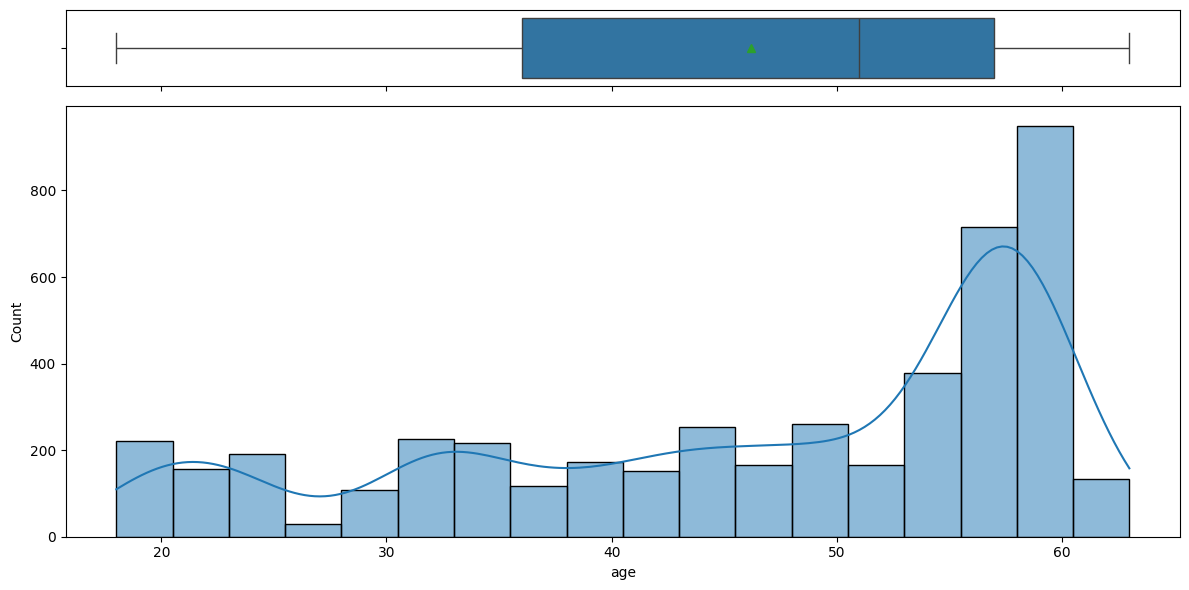

In [30]:
hist_box(data, 'age')

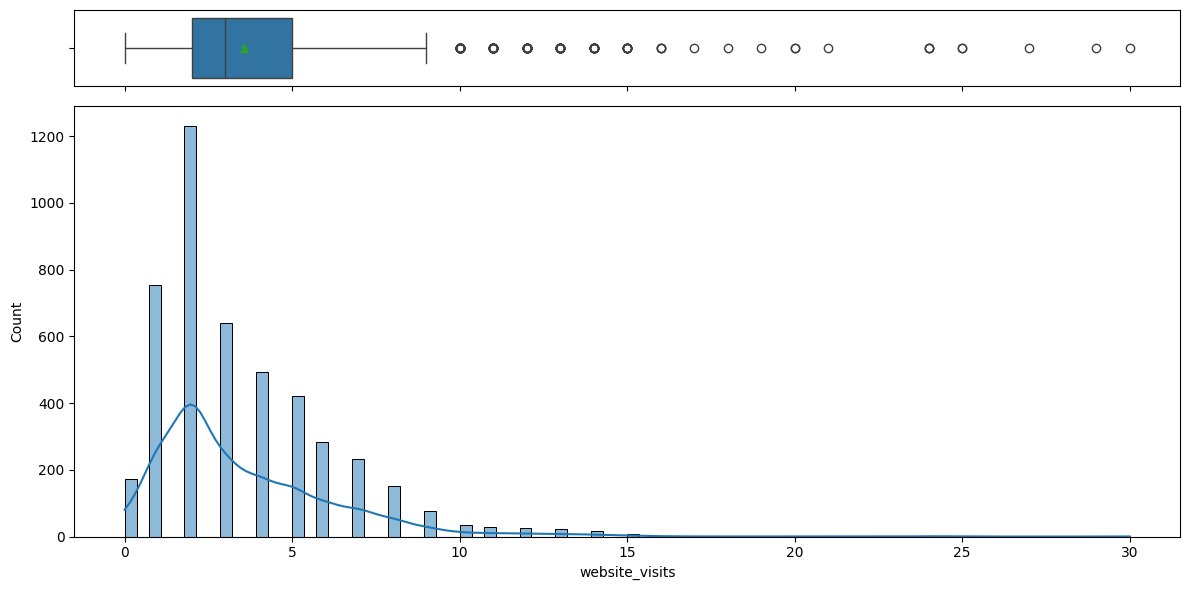

In [31]:
hist_box(data, 'website_visits')

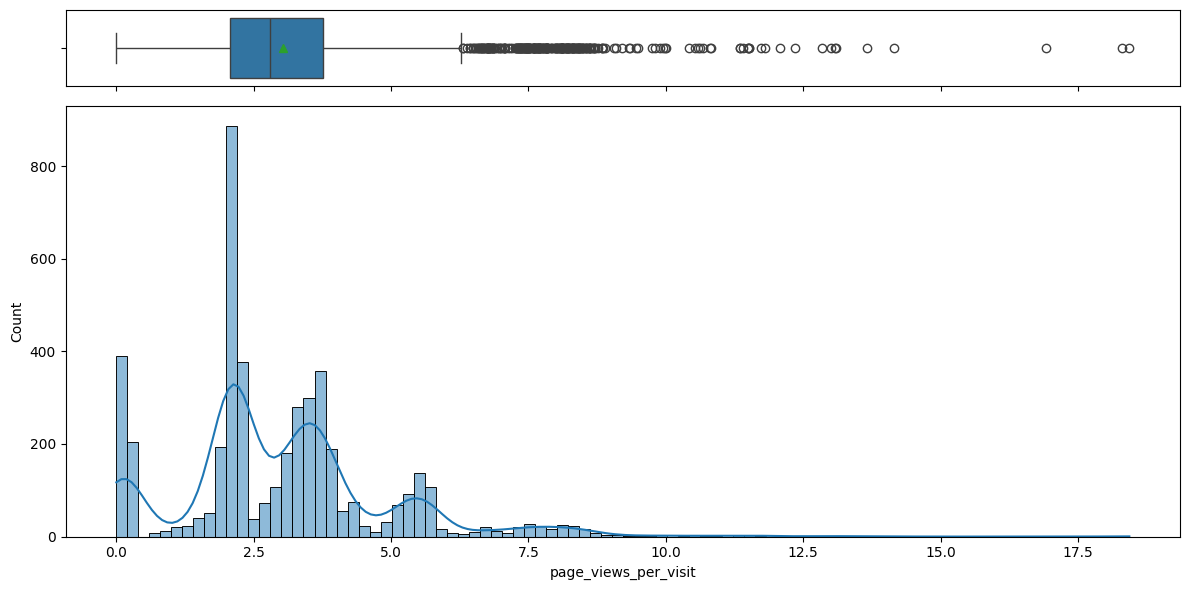

In [32]:
hist_box(data, 'page_views_per_visit')

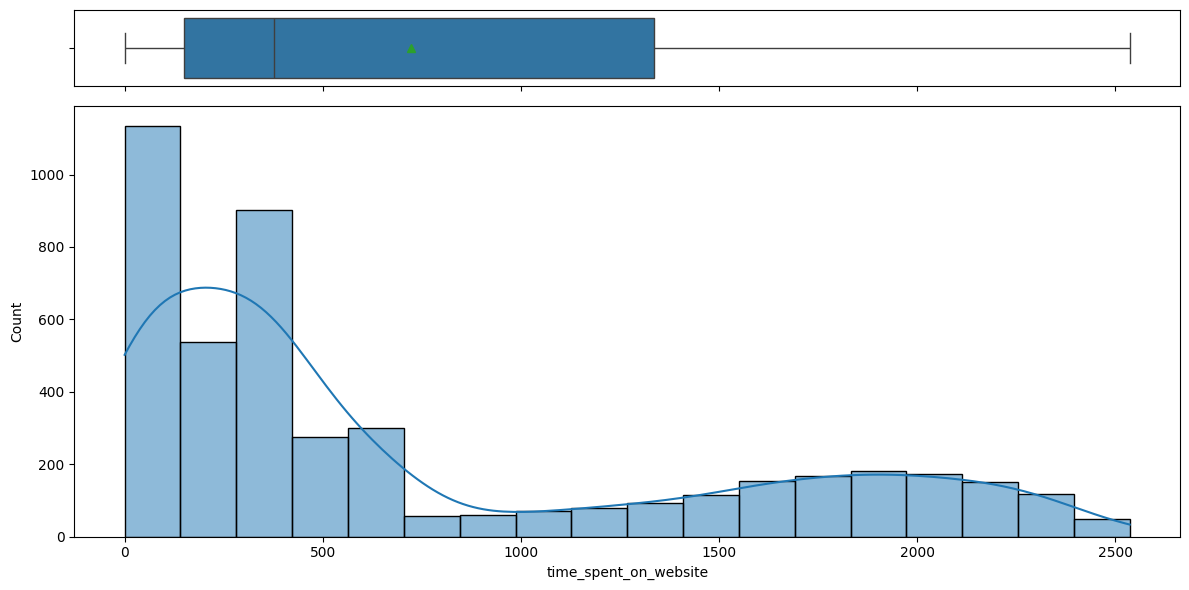

In [33]:
hist_box(data, 'time_spent_on_website')

**Observation:**
- `age`  slight right skew and visible high-end outliers.
- `website_visits` and `time_spent_on_website` are right-skewed with long tails.
- `page_views_per_visit` also shows extreme outlier values on the upper end.

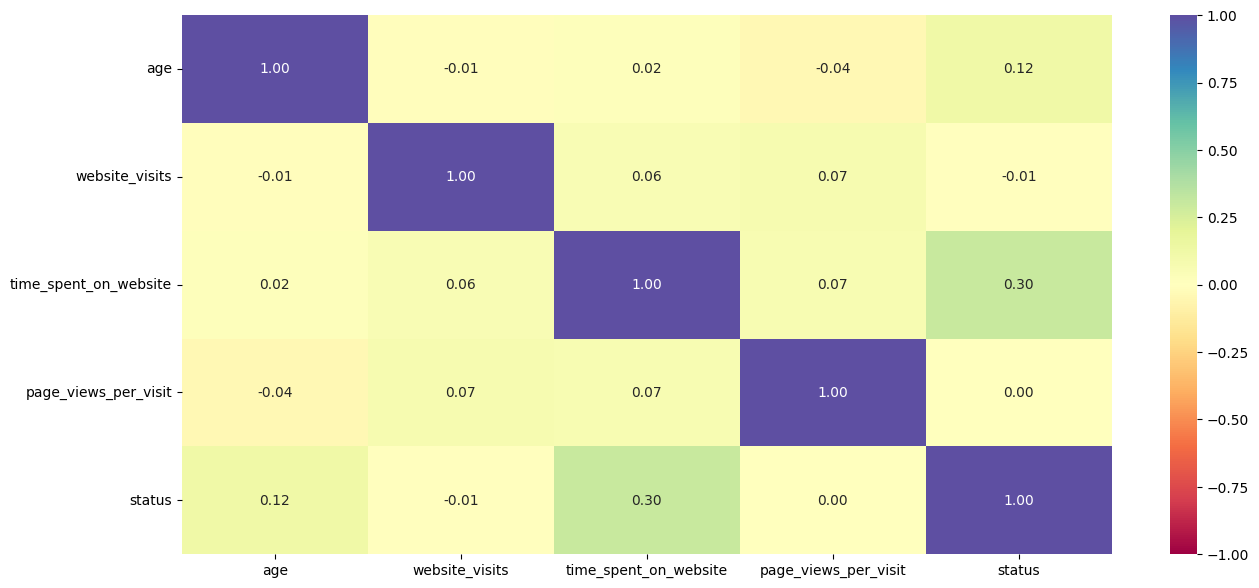

In [34]:
numeric_data = data.select_dtypes(include=np.number)

# Create heatmap
plt.figure(figsize=(15, 7))
sns.heatmap(numeric_data.corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral")
plt.show()

**Observation:**
- `time_spent_on_website` has the **strongest positive correlation** with `status` (~0.38) among all numerical features

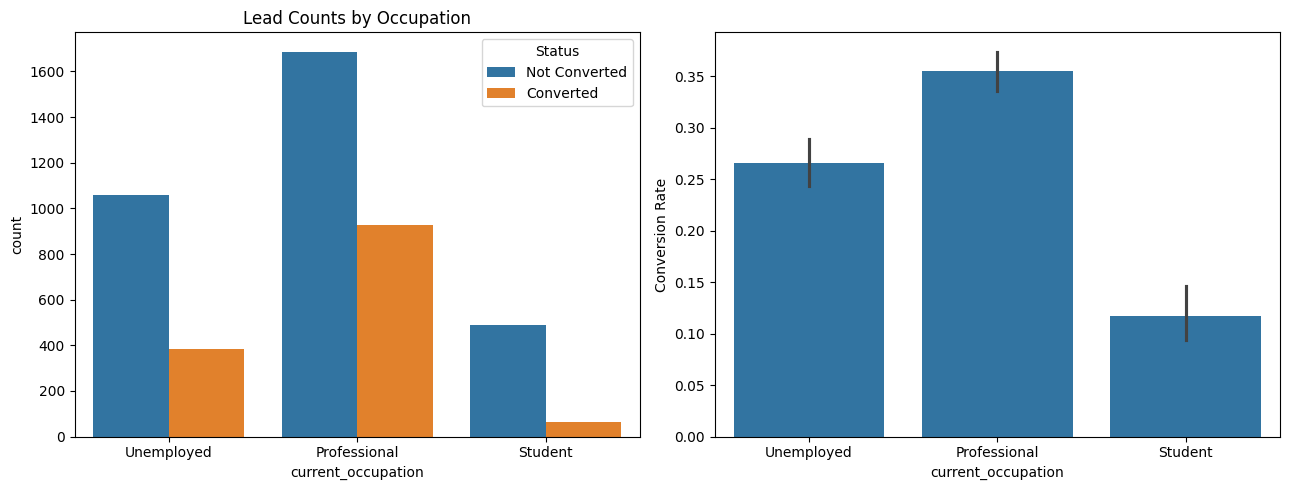

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.countplot(data=data, x='current_occupation', hue='status', ax=axes[0])
axes[0].set_title('Lead Counts by Occupation')
axes[0].legend(title='Status', labels=['Not Converted', 'Converted'])
sns.barplot(data=data, x='current_occupation', y='status', ax=axes[1])
axes[1].set_ylabel('Conversion Rate')
plt.tight_layout()
plt.show()

**Observation :**
- **Professionals** have the highest conversion rate.
- **Students** have the lowest conversion rate

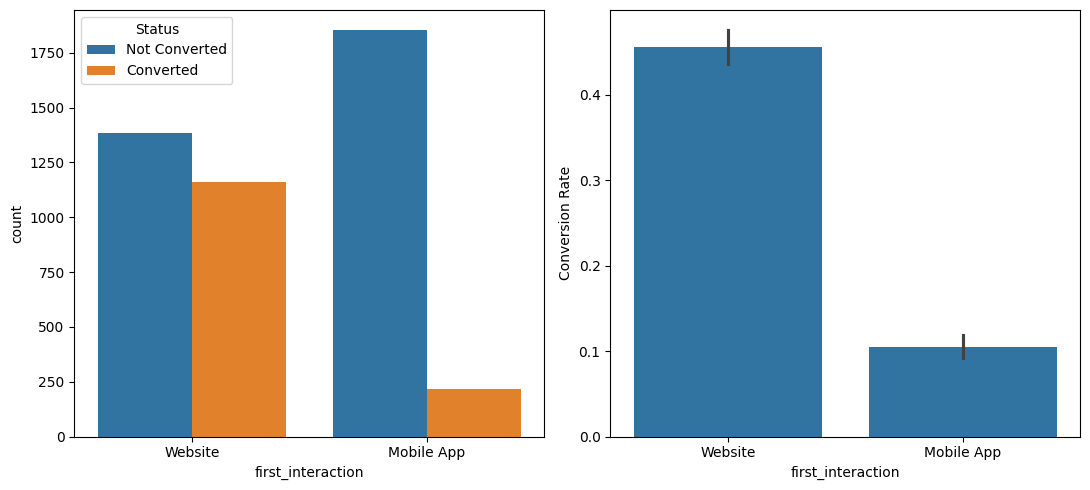

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
sns.countplot(data=data, x='first_interaction', hue='status', ax=axes[0])
axes[0].legend(title='Status', labels=['Not Converted', 'Converted'])
sns.barplot(data=data, x='first_interaction', y='status', ax=axes[1])
axes[1].set_ylabel('Conversion Rate')
plt.tight_layout()
plt.show()

- Leads whose first interaction was via the **Website** convert at a noticeably higher rate than those from the **Mobile App**.


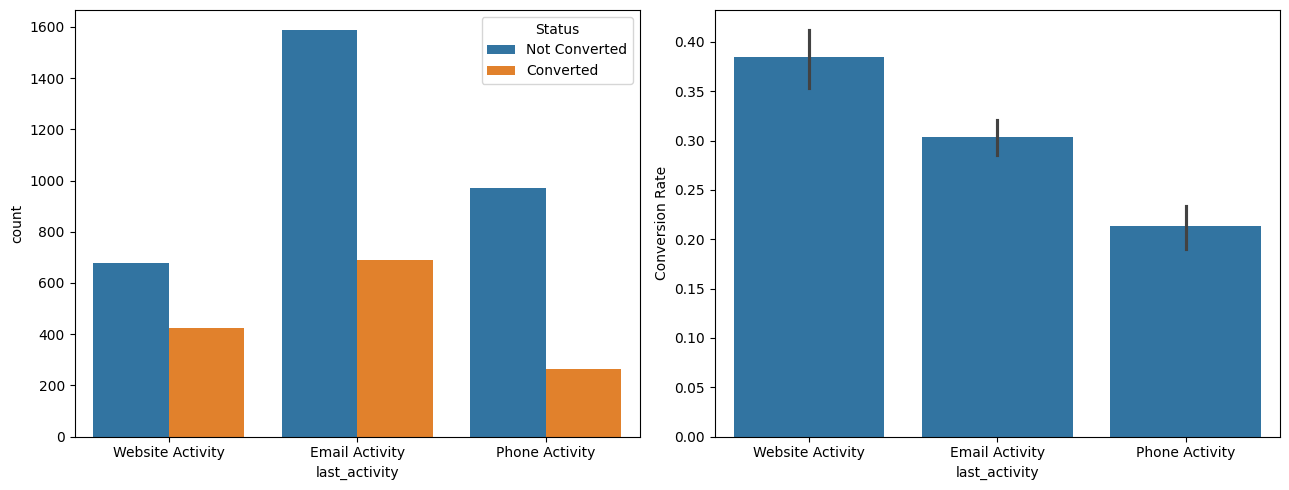

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.countplot(data=data, x='last_activity', hue='status', ax=axes[0])
axes[0].legend(title='Status', labels=['Not Converted', 'Converted'])
sns.barplot(data=data, x='last_activity', y='status', ax=axes[1])
axes[1].set_ylabel('Conversion Rate')
plt.tight_layout()
plt.show()

**Observation :**
- **Website Activity** has the highest conversion rate among last interaction modes.

## Data Preprocessing

- Missing value treatment (if needed)
- Feature engineering (if needed)
- Outlier detection and treatment (if needed)
- Preparing data for modeling
- Any other preprocessing steps (if needed)

In [54]:
def cap_outliers_iqr(df, col, factor=3.0):
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - factor * iqr, q3 + factor * iqr
    df[col] = df[col].clip(lower, upper)
    return df

In [55]:
num_cols = ['age', 'website_visits', 'time_spent_on_website', 'page_views_per_visit']
df_clean = data.copy()
for col in num_cols:
    df_clean = cap_outliers_iqr(df_clean, col)


**Observation:**
Outliers were detected in `time_spent_on_website`, `website_visits`, and `page_views_per_visit`.

In [60]:
df = df_clean.copy()
df.drop(columns=['ID'], inplace=True)

binary_cols = ['print_media_type1', 'print_media_type2',
               'digital_media', 'educational_channels', 'referral']

for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

df['profile_completed'] = df['profile_completed'].map({'Low': 0, 'Medium': 1, 'High': 2})

df = pd.get_dummies(df,columns=['current_occupation', 'first_interaction', 'last_activity'],
                          drop_first=True)
print(df.dtypes)


age                                 int64
profile_completed                   int64
website_visits                      int64
time_spent_on_website               int64
page_views_per_visit              float64
print_media_type1                   int64
print_media_type2                   int64
digital_media                       int64
educational_channels                int64
referral                            int64
status                              int64
current_occupation_Student           bool
current_occupation_Unemployed        bool
first_interaction_Website            bool
last_activity_Phone Activity         bool
last_activity_Website Activity       bool
dtype: object


In [61]:
df.head()

,age,profile_completed,website_visits,time_spent_on_website,page_views_per_visit,print_media_type1,print_media_type2,digital_media,educational_channels,referral,status,current_occupation_Student,current_occupation_Unemployed,first_interaction_Website,last_activity_Phone Activity,last_activity_Website Activity
0,57,2,7,1639,1.86100,1,0,1,0,0,1,False,True,True,False,True
1,56,1,2,83,0.32000,0,0,0,1,0,0,False,False,False,False,True
2,52,1,3,330,0.07400,0,0,1,0,0,0,False,False,True,False,True
3,53,2,4,464,2.05700,0,0,0,0,0,1,False,True,True,False,True
4,23,2,4,600,8.79175,0,0,0,0,0,0,True,False,True,False,False


**Observation:**
- `profile_completed` received **ordinal encoding** because the categories have a meaningful order.
- `current_occupation`, `first_interaction`, and `last_activity` received **One-Hot Encoding**

In [74]:
X = df.drop(columns=['status'])
y = df['status']

In [75]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, shuffle = True, random_state = 1,stratify=y)

In [76]:
# Checking the shape of the train and test data
print("Shape of Training set : ", X_train.shape)
print("Shape of test set : ", X_test.shape)

Shape of Training set :  (3689, 15)
Shape of test set :  (923, 15)


## EDA

- It is a good idea to explore the data once again after manipulating it.

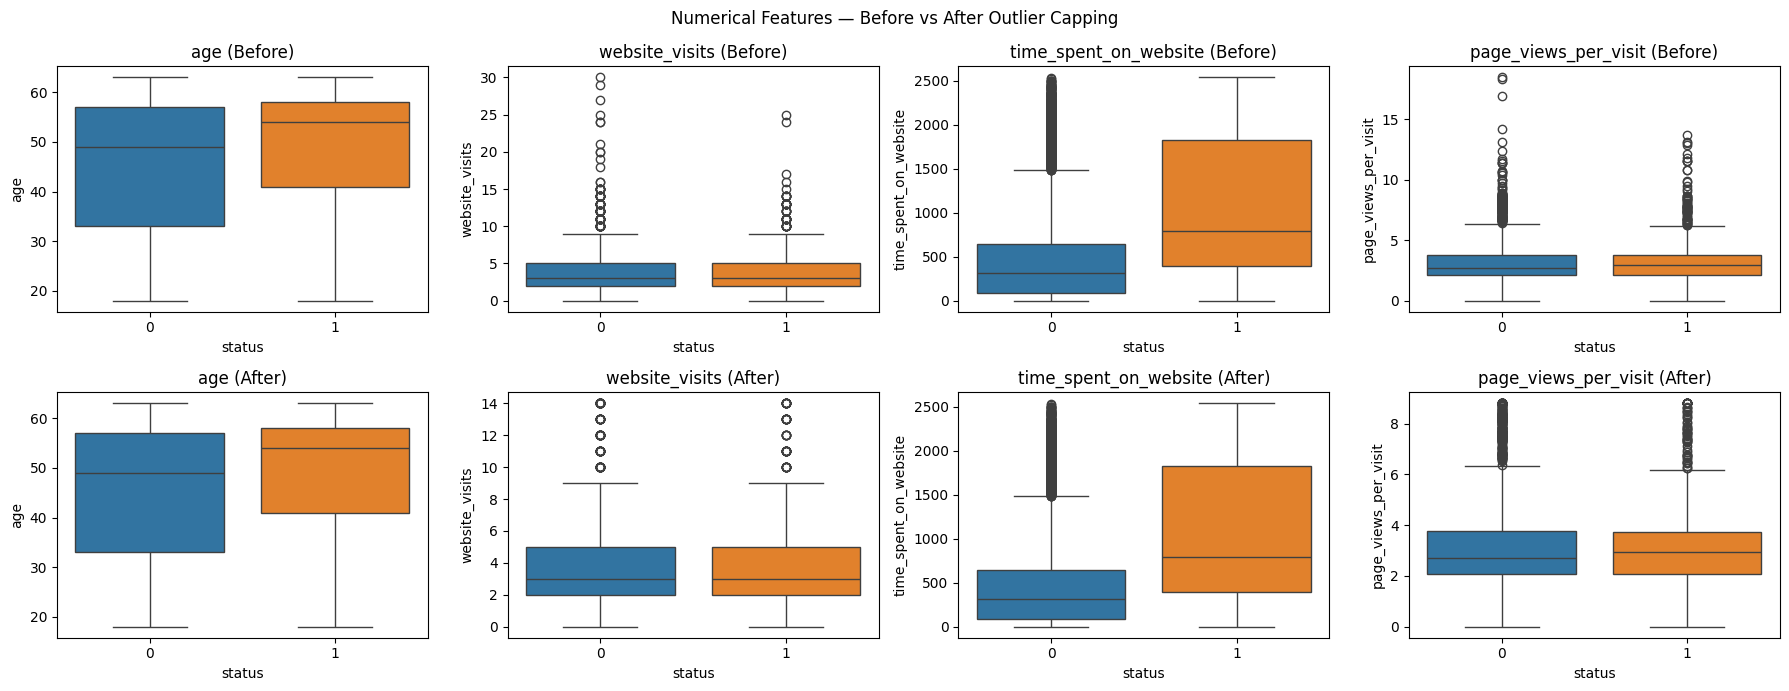

In [68]:
fig, axes = plt.subplots(2, 4, figsize=(18, 7))
fig.suptitle('Numerical Features — Before vs After Outlier Capping')

for i, col in enumerate(num_cols):
    sns.boxplot(data=data, x='status', y=col, hue='status', legend=False, ax=axes[0, i])
    axes[0, i].set_title(f'{col} (Before)')

    sns.boxplot(data=df, x='status', y=col, hue='status', legend=False, ax=axes[1, i])
    axes[1, i].set_title(f'{col} (After)')

plt.tight_layout()
plt.show()

## Building a Decision Tree model

In [83]:
# Called after every model to display metrics and confusion matrix.

def evaluate_model(model, X_tr, X_te, y_tr, y_te, model_name='Model'):
    """Print metrics table and confusion matrix for train and test sets."""

    y_pred_tr = model.predict(X_tr)
    y_pred_te = model.predict(X_te)
    y_prob_te = model.predict_proba(X_te)[:, 1]

    metrics = {
        'Accuracy' : [accuracy_score(y_tr, y_pred_tr),  accuracy_score(y_te, y_pred_te)],
        'Precision': [precision_score(y_tr, y_pred_tr), precision_score(y_te, y_pred_te)],
        'Recall'   : [recall_score(y_tr, y_pred_tr),    recall_score(y_te, y_pred_te)],
        'F1-Score' : [f1_score(y_tr, y_pred_tr),        f1_score(y_te, y_pred_te)]
    }

    results_df = pd.DataFrame(metrics, index=['Train', 'Test']).T
    styled = results_df.style \
        .format('{:.4f}') \
        .background_gradient(cmap='RdYlGn', axis=None, vmin=0.5, vmax=1.0) \
        .set_caption(f'Metrics — {model_name}')
    display(styled)

    # Confusion matrix
    cm = confusion_matrix(y_te, y_pred_te)
    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay(confusion_matrix=cm,
                           display_labels=['Not Converted', 'Converted']).plot(
        ax=ax, cmap='Blues', colorbar=False
    )
    ax.set_title(f'Confusion Matrix — {model_name} (Test Set)', fontsize=11)
    plt.tight_layout()
    plt.show()

    return {
        'accuracy_train': accuracy_score(y_tr, y_pred_tr),
        'accuracy_test' : accuracy_score(y_te, y_pred_te),
        'recall_test'   : recall_score(y_te, y_pred_te),
        'f1_test'       : f1_score(y_te, y_pred_te)
    }


In [78]:
model_dt = DecisionTreeClassifier()
model_dt.fit(X_train, y_train)

DecisionTreeClassifier()

In [84]:
print(f'Tree depth   : {model_dt.get_depth()}')
print(f'Leaf nodes   : {model_dt.get_n_leaves()}')

Tree depth   : 22
Leaf nodes   : 504


,Train,Test
Accuracy,0.9995,0.8039
Precision,0.9991,0.6690
Recall,0.9991,0.6812
F1-Score,0.9991,0.6750


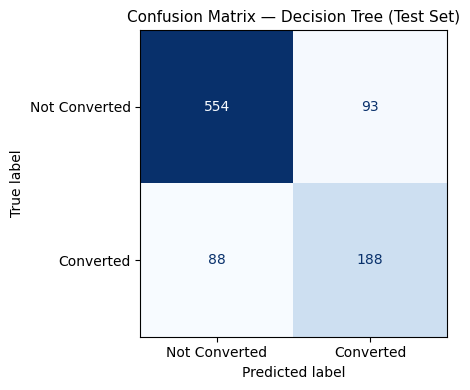

In [85]:
results_dt_base = evaluate_model(model_dt, X_train, X_test, y_train, y_test,'Decision Tree')

**Observation — Decision Tree Baseline:**
- The unconstrained tree reaches **very high training accuracy (~100%)** but lower test accuracy — a classic sign of **overfitting**.
- The tree is extremely deep with many leaf nodes, meaning it has memorized noise in the training data rather than learning generalizable patterns.
- Pruning is clearly necessary to improve generalization.

## Do we need to prune the tree?

**Observation — Decision Tree Baseline:**
- The unconstrained tree reaches **very high training accuracy (~100%)** but lower test accuracy — a classic sign of **overfitting**.
- The tree is extremely deep with many leaf nodes, meaning it has memorized noise in the training data rather than learning generalizable patterns.
- Pruning is clearly necessary to improve generalization.


Best hyperparameters:
{'class_weight': 'balanced', 'max_depth': 3, 'min_samples_leaf': 5, 'min_samples_split': 10}
Best CV recall: 0.8874

Optimized tree depth : 3
Optimized tree leaves: 8


,Train,Test
Accuracy,0.8116,0.7963
Precision,0.6334,0.6158
Recall,0.8756,0.8478
F1-Score,0.7350,0.7134


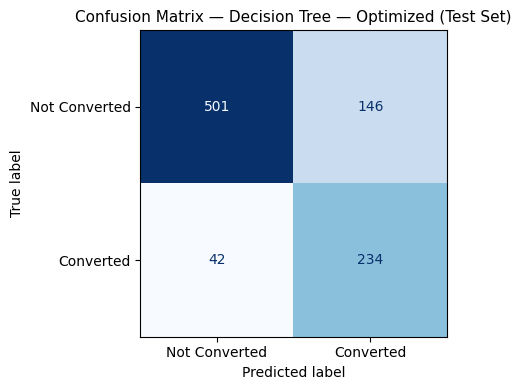

In [89]:
param_grid_dt = {
    'max_depth'        : [3, 5, 7, 10, None],
    'min_samples_leaf' : [5, 10, 20, 30],
    'min_samples_split': [10, 20, 50],
    'class_weight'     : [None, 'balanced'],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)

grid_dt = GridSearchCV(
    estimator=DecisionTreeClassifier(criterion='gini', random_state=1),
    param_grid=param_grid_dt,
    cv=cv,
    scoring='recall',
    n_jobs=-1,
    verbose=0
)
grid_dt.fit(X_train, y_train)

print('\nBest hyperparameters:')
print(grid_dt.best_params_)
print(f'Best CV recall: {grid_dt.best_score_:.4f}')

# ── Evaluate the pruned tree ─────────────────────────────────────────────────
dt_best_model = grid_dt.best_estimator_
print(f'\nOptimized tree depth : {dt_best_model.get_depth()}')
print(f'Optimized tree leaves: {dt_best_model.get_n_leaves()}')

results_dt_best = evaluate_model(
    dt_best_model, X_train, X_test, y_train, y_test,
    'Decision Tree — Optimized'
)

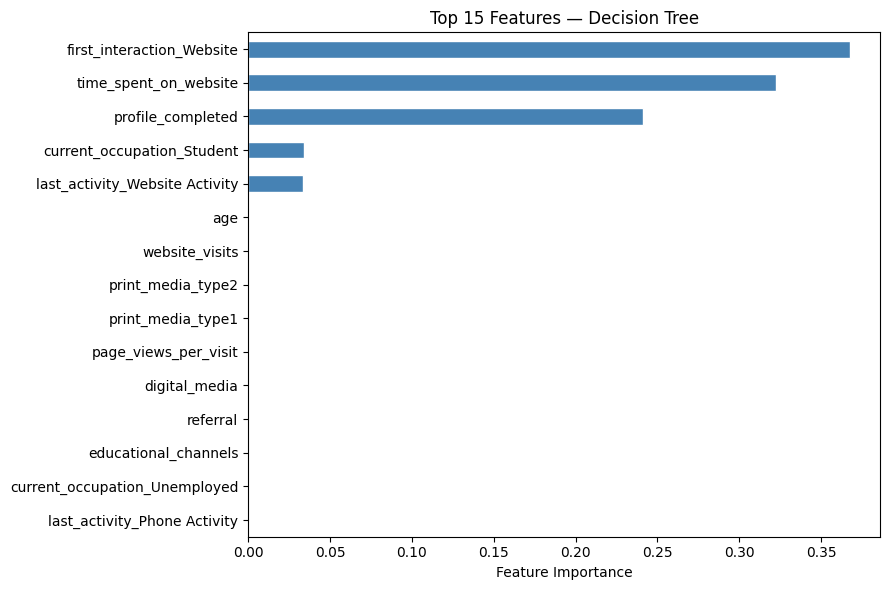

first_interaction_Website         0.367631
time_spent_on_website             0.322773
profile_completed                 0.241198
current_occupation_Student        0.033938
last_activity_Website Activity    0.033748
age                               0.000712
website_visits                    0.000000
print_media_type2                 0.000000
print_media_type1                 0.000000
page_views_per_visit              0.000000
dtype: float64


In [93]:
feat_imp_dt = pd.Series(
    dt_best_model.feature_importances_, index=X.columns
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 6))
feat_imp_dt.head(15).plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.invert_yaxis()
ax.set_title('Top 15 Features — Decision Tree', fontsize=12)
ax.set_xlabel('Feature Importance')
plt.tight_layout()
plt.show()
print(feat_imp_dt.head(10))

**Observation:**
- **Top features by Gini importance**:  `first_interaction_Website`,`time_spent_on_website`, and `profile_completed` dominate — fully consistent with EDA insights.

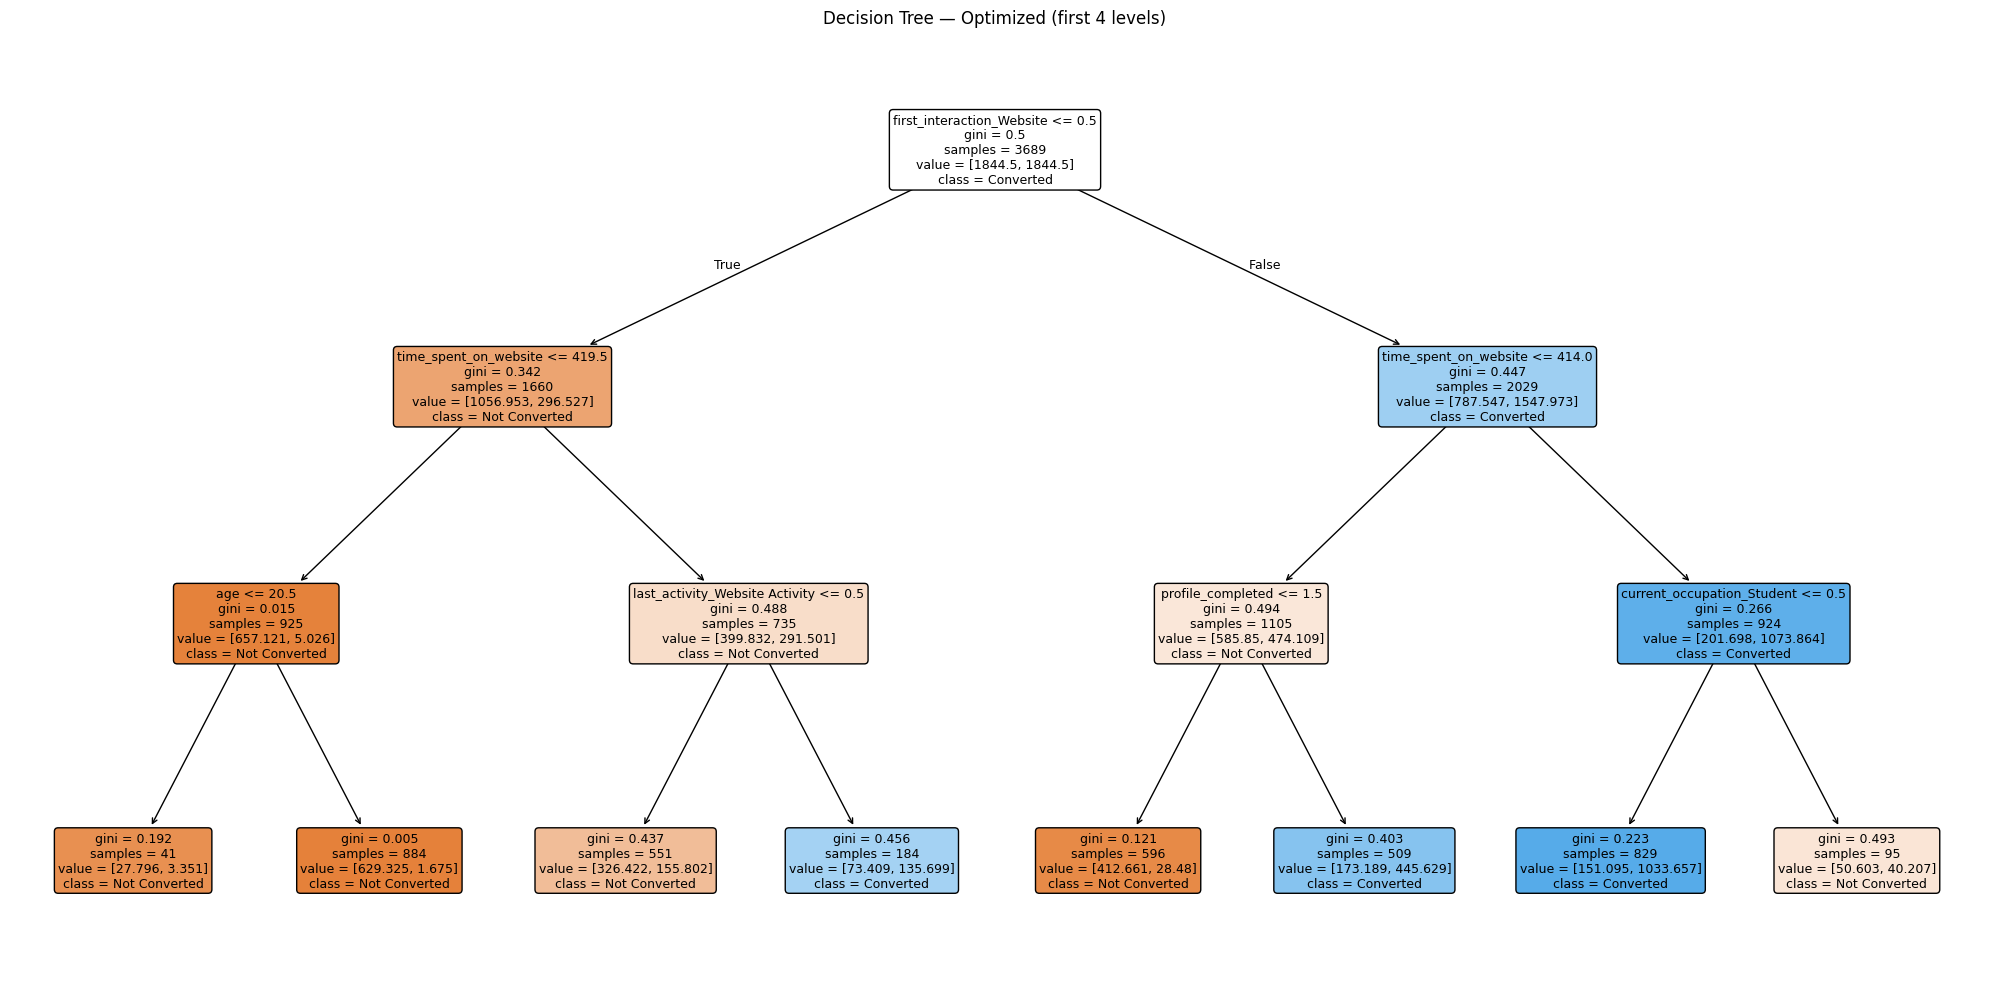

In [94]:
fig, ax = plt.subplots(figsize=(20, 10))
plot_tree(
    dt_best_model, max_depth=4,
    feature_names=X.columns,
    class_names=['Not Converted', 'Converted'],
    filled=True, rounded=True, impurity=True,
    ax=ax, fontsize=9
)
ax.set_title('Decision Tree — Optimized (first 4 levels)', fontsize=12)
plt.tight_layout()
plt.show()

# **Observation — Decision Tree Pruning:**
- After GridSearchCV optimization, the gap between train and test accuracy **narrows significantly**, indicating better generalization.
- The optimized tree achieves **~84%

## Building a Random Forest model

,Train,Test
Accuracy,0.9995,0.8581
Precision,0.9982,0.7821
Recall,1.0000,0.7283
F1-Score,0.9991,0.7542


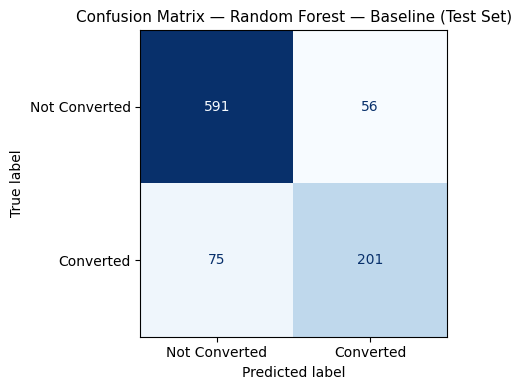

In [96]:
rf_base = RandomForestClassifier(n_estimators=100, random_state=1, n_jobs=-1)
rf_base.fit(X_train, y_train)

results_rf_base = evaluate_model(
    rf_base, X_train, X_test, y_train, y_test,
    'Random Forest — Baseline'
)

## Do we need to prune the tree?

**Observation — Decision Tree Baseline:**
- The model reaches **very high training accuracy (~100%)**  a classic sign of **overfitting**.
- Pruning is clearly necessary to improve generalization.

Fitting 5 folds for each of 144 candidates, totalling 720 fits

Best hyperparameters:
{'class_weight': 'balanced', 'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 10, 'n_estimators': 200}
Best CV recall: 0.8738


,Train,Test
Accuracy,0.8344,0.8353
Precision,0.6687,0.6732
Recall,0.8819,0.8732
F1-Score,0.7607,0.7603


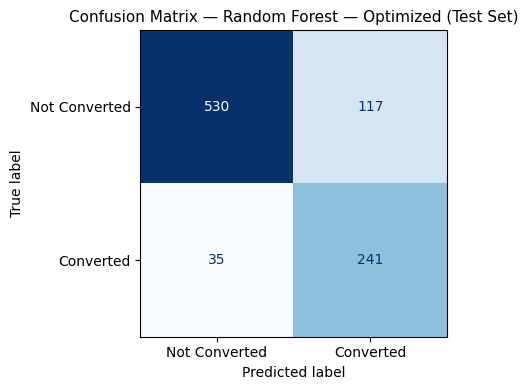

In [98]:
param_grid_rf = {
    'n_estimators'    : [100, 200, 300],
    'max_depth'       : [5, 10, 15, None],
    'max_features'    : ['sqrt', 'log2'],
    'min_samples_leaf': [1, 5, 10],
    'class_weight'    : [None, 'balanced'],
}

grid_rf = GridSearchCV(
    estimator=RandomForestClassifier(random_state=1, n_jobs=-1),
    param_grid=param_grid_rf,
    cv=cv,
    scoring='recall',
    n_jobs=-1,
    verbose=1
)
grid_rf.fit(X_train, y_train)

print('\nBest hyperparameters:')
print(grid_rf.best_params_)
print(f'Best CV recall: {grid_rf.best_score_:.4f}')

# ── Evaluate the optimized Random Forest ─────────────────────────────────────
rf_best = grid_rf.best_estimator_

results_rf_best = evaluate_model(
    rf_best, X_train, X_test, y_train, y_test,
    'Random Forest — Optimized'
)

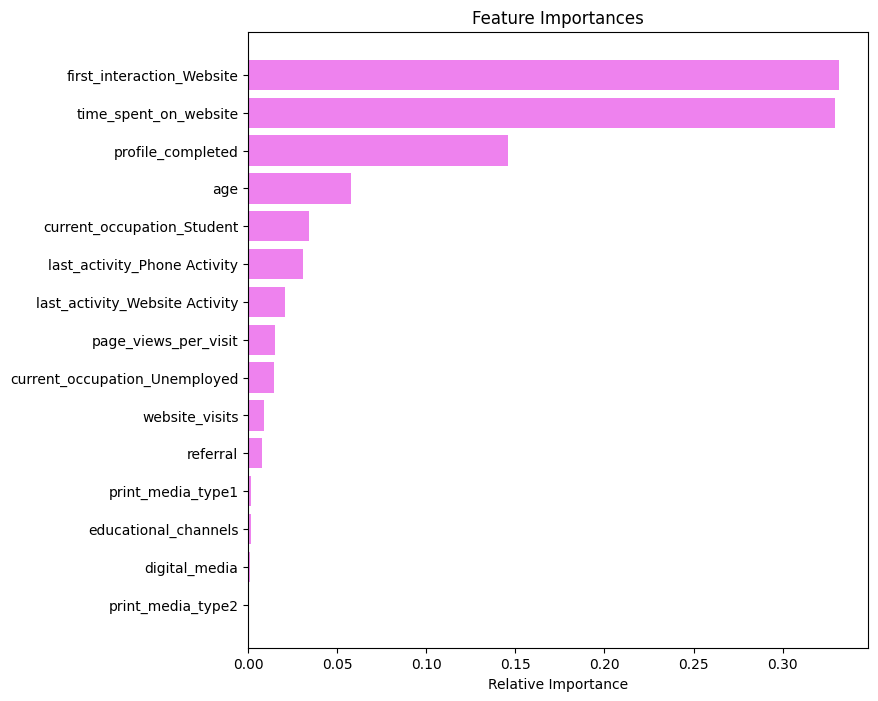

In [100]:
importances = rf_best.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(8, 8))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
plt.yticks(range(len(indices)), [X.columns[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()


**Observation — Random Forest Tuning & Model Comparison:**
- After GridSearchCV, the optimized RF reduces the train-test gap, confirming **better generalization**.
- **Feature importances are consistent** with both the EDA and the Decision Tree:
  `time_spent_on_website`, `first_interaction_Website`, and `profile_completed` are the top 3 drivers.
- Only **3–5 features** explain 80% of the model's total predictive power.
- The RF consistently **outperforms the single Decision Tree** on F1-Score and ROC-AUC.
- The DT Optimized achieves slightly higher Recall, but at the cost of lower Precision — the RF offers a better overall balance.

## Actionable Insights and Recommendations

In [102]:
comparison = pd.DataFrame({
    'DT Optimized': results_dt_best,
    'RF Optimized': results_rf_best
}).T
comparison.columns = ['Acc. Train', 'Acc. Test', 'Recall Test', 'F1 Test']
styled = comparison.style \
    .format('{:.4f}') \
    .background_gradient(cmap='RdYlGn', axis=0) \
    .set_caption('Model Comparison — All Metrics')

display(styled)

,Acc. Train,Acc. Test,Recall Test,F1 Test
DT Optimized,0.8116,0.7963,0.8478,0.7134
RF Optimized,0.8344,0.8353,0.8732,0.7603


### Recommendations
**1. Recommended model for production: Random Forest Optimized** — Best F1 trade-off.

**2. Invest in website engagement over mobile app**  

**3. Segment by occupation for personalized messaging**  
- **Unemployed leads**: emphasize fast career transition and job placement outcomes.
- **Professionals**: highlight upskilling, salary growth, and industry recognition.
- **Students**: offer flexible payment options and career-entry-level programs.

### Profile of a High-Potential Lead

- First interaction via the **Website** (not Mobile App)  
- Significant **time spent on website** (above dataset median)  
- Multiple **page views per visit** (exploring content deeply)  
- **Unemployed or Professional** occupation  
interaction was **Phone Activity** or **Website Activity**  
- Exposed to **referral** or **educational channels**